# Dataset GNSS–ERA5 per rain nowcasting

Questo notebook costruisce un dataset supervisionato per prevedere se pioverà nell'ora successiva sopra MATE00ITA. Le osservazioni GNSS sono elaborate alla granularità nativa di 5 minuti; il dataset finale è orario perché la pioggia ERA5 è disponibile come accumulo dell'ora precedente.

Target: `is_rain = 1` quando `rain_next_hour_mm > 0.0`. Tutti i timestamp sono UTC.

## Perché non assegniamo il target a ogni riga da 5 minuti

Open-Meteo marca la pioggia alle 01:00 come somma nell'intervallo (00:00, 01:00]. Quella misura può etichettare le feature note alle 00:00, ma non quelle delle 00:55: queste ultime conterrebbero quasi tutta l'ora che si vuole prevedere. Campionare le feature esattamente allo scoccare dell'ora evita questo leakage.

In [1]:
from datetime import date
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd()
if not (ROOT / 'gnss_weather').exists():
    ROOT = ROOT.parent

from gnss_weather.ml_dataset import build_rain_dataset, write_dataset

STATION = 'MATE00ITA'
START = date(2024, 7, 1)
END = date(2026, 8, 20)
RAIN_THRESHOLD_MM = 0.
ERA5_PATH = ROOT / 'data/meteo/MATE00ITA_era5_2024-07-01_2026-08-20.csv'
TRO_ROOT = ROOT / 'data/products/reference_ztd'
METADATA_PATH = ROOT / 'data/products/station/MATE00ITA.json'
OUTPUT = ROOT / 'data/derived/ml/MATE00ITA_rain_hourly_2024-07-01_2026-08-20.csv'

## Costruzione fisica e feature engineering

La pipeline interpola pressione e temperatura ERA5 alle epoche TRO, calcola `ZHD`, quindi `ZWD = ZTD - ZHD` e converte ZWD in PWV. Le feature sono tutte numeriche e quindi esportabili successivamente con CatBoost in ONNX-ML.

Per PWV, ZWD e ZTD aggiungiamo differenze a 30 minuti, 1 ora e 3 ore, più media e deviazione standard mobili a 1 e 3 ore. Ora UTC e giorno dell'anno sono codificati con seno/coseno.

In [2]:
tro_paths = sorted(TRO_ROOT.glob('*.TRO.gz'))
dataset = build_rain_dataset(
    tro_paths=tro_paths,
    era5_path=ERA5_PATH,
    station_metadata_path=METADATA_PATH,
    start=START,
    end=END,
    rain_threshold_mm=RAIN_THRESHOLD_MM,
)
csv_path, report_path = write_dataset(dataset, OUTPUT)
csv_path, report_path

(WindowsPath('C:/Users/vince/repos/gnss-weather/data/derived/ml/MATE00ITA_rain_hourly_2024-07-01_2026-08-20.csv'),
 WindowsPath('C:/Users/vince/repos/gnss-weather/data/derived/ml/MATE00ITA_rain_hourly_2024-07-01_2026-08-20.json'))

In [3]:
pd.Series(dataset.report, name='value').to_frame()

,value
station,MATE00ITA
start,2024-07-01
end,2026-08-20
rain_target,ERA5 rain_mm stamped at epoch+1h (sum of prece...
rain_threshold_mm_strictly_greater_than,0.0
gnss_native_interval_minutes,5
training_interval_minutes,60
tro_days_available,635
tro_days_missing,146
missing_tro_dates,"[2024-07-08, 2024-07-20, 2024-07-26, 2024-08-0..."


## Dataset risultante

Le colonne `epoch_utc`, `target_window_end_utc`, `rain_next_hour_mm`, `is_rain` e `ztd_source` sono metadati/target. Solo `dataset.feature_columns` deve essere passato al modello.

In [4]:
hourly = dataset.hourly
print(f'Righe complete: {len(hourly):,}')
print(f'Feature: {len(dataset.feature_columns)}')
print(f'Eventi pioggia: {int(hourly.is_rain.sum()):,} ({hourly.is_rain.mean():.2%})')
hourly.head(3)

Righe complete: 15,033
Feature: 31
Eventi pioggia: 1,897 (12.62%)


,target_window_end_utc,rain_next_hour_mm,is_rain,ztd_source,pwv_mm,zwd_mm,ztd_mm,pwv_mm_delta_30m,pwv_mm_delta_1h,pwv_mm_delta_3h,...,ztd_mm_mean_3h,ztd_mm_std_3h,hour_sin,hour_cos,doy_sin,doy_cos,solar_zenith_deg,pressure_hpa,temperature_c,ztd_sigma_mm
epoch_utc,,,,,,,,,,,,,,,,,,,,,
2024-07-01 03:00:00+00:00,2024-07-01 04:00:00+00:00,0.0,0,igs_final_tro,17.135803,106.064914,2284.8,0.379219,1.292273,3.964246,...,2271.061111,8.783231,0.707107,0.707107,0.008537,-0.999964,94.827614,956.4,23.0,1.6
2024-07-01 04:00:00+00:00,2024-07-01 05:00:00+00:00,0.0,0,igs_final_tro,18.657310,115.453691,2295.1,0.898191,1.521507,5.035880,...,2280.330556,9.135791,0.866025,0.500000,0.007820,-0.999969,85.123001,956.8,23.1,1.4
2024-07-01 05:00:00+00:00,2024-07-01 06:00:00+00:00,0.0,0,igs_final_tro,20.845104,128.414661,2309.2,0.861403,2.187794,5.001575,...,2291.836111,9.572970,0.965926,0.258819,0.007103,-0.999975,74.582563,957.3,24.9,1.7


## Controlli rapidi

La classe positiva è rara: accuracy da sola sarebbe fuorviante. Nel notebook di training useremo almeno PR-AUC, Brier score, precision e recall, con split rigorosamente cronologico.

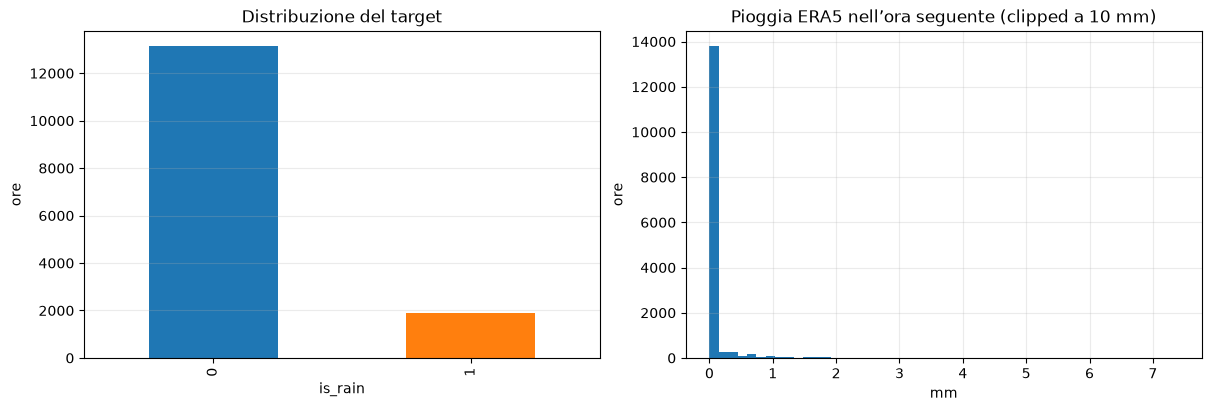

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
hourly['is_rain'].value_counts().sort_index().plot.bar(ax=axes[0], color=['tab:blue', 'tab:orange'])
axes[0].set(title='Distribuzione del target', xlabel='is_rain', ylabel='ore')
axes[0].grid(axis='y', alpha=0.25)

hourly['rain_next_hour_mm'].clip(upper=10).hist(ax=axes[1], bins=50, color='tab:blue')
axes[1].set(title='Pioggia ERA5 nell’ora seguente (clipped a 10 mm)', xlabel='mm', ylabel='ore')
axes[1].grid(alpha=0.25)
plt.show()

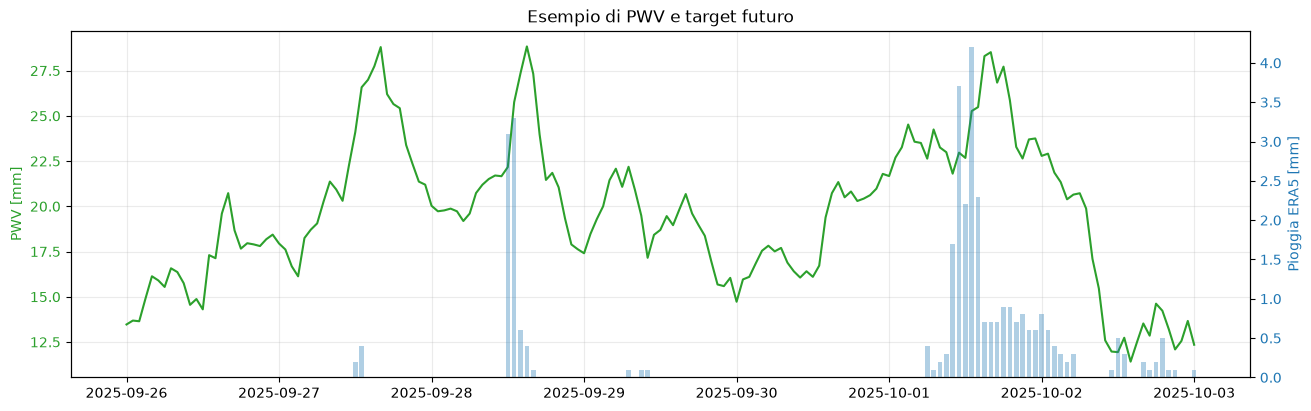

In [6]:
rainy = hourly.index[hourly['is_rain'].eq(1)]
if len(rainy):
    start_plot = rainy[len(rainy) // 2].floor('D') - pd.Timedelta(days=2)
    view = hourly.loc[start_plot:start_plot + pd.Timedelta(days=7)]
    fig, axis = plt.subplots(figsize=(13, 4), constrained_layout=True)
    axis.plot(view.index, view['pwv_mm'], color='tab:green', label='PWV')
    axis.set_ylabel('PWV [mm]', color='tab:green')
    axis.tick_params(axis='y', labelcolor='tab:green')
    rain_axis = axis.twinx()
    rain_axis.bar(view.index, view['rain_next_hour_mm'], width=0.03, alpha=0.35, color='tab:blue', label='pioggia ora seguente')
    rain_axis.set_ylabel('Pioggia ERA5 [mm]', color='tab:blue')
    rain_axis.tick_params(axis='y', labelcolor='tab:blue')
    axis.set_title('Esempio di PWV e target futuro')
    axis.grid(alpha=0.25)
    plt.show()

## Output per il prossimo notebook

Il CSV esportato è pronto per split temporale, CatBoost, calibrazione e ONNX. Il JSON affiancato registra feature, soglia, gap TRO e definizione temporale del target.